In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy.sparse import issparse
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import  SelectKBest, f_classif, RFE
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier

### Step 1: Load and inspect the data

In [2]:
# Get the current directory of the notebook
current_folder = os.path.dirname(os.path.realpath('__file__'))

# Change the working directory to the current folder
os.chdir(current_folder)

# Confirm the current working directory
print(f"Current working directory: {os.getcwd()}")

# 1. Load Data
data = pd.read_csv("trainingset.txt")
data.head()

Current working directory: C:\Users\colin\My Drive\Data Science Masters TU059\Machine Learning\Assignment


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,44,JobCat9,single,secondary,no,29,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
1,47,JobCat3,married,unknown,no,1506,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
2,31,unknown,single,unknown,no,1,no,no,unknown,5,may,0,1,-1,0,unknown,TypeA
3,26,JobCat6,single,tertiary,no,447,yes,yes,unknown,5,may,0,1,-1,0,unknown,TypeA
4,42,JobCat4,divorced,tertiary,yes,2,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA


In [3]:
# Explore the data
print("Dataset Info:\n", data.info())
print("\nTarget Variable Distribution:\n", data['y'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27272 entries, 0 to 27271
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        27272 non-null  int64 
 1   job        27272 non-null  object
 2   marital    27272 non-null  object
 3   education  27272 non-null  object
 4   default    27272 non-null  object
 5   balance    27272 non-null  int64 
 6   housing    27272 non-null  object
 7   loan       27272 non-null  object
 8   contact    27272 non-null  object
 9   day        27272 non-null  int64 
 10  month      27272 non-null  object
 11  duration   27272 non-null  int64 
 12  campaign   27272 non-null  int64 
 13  pdays      27272 non-null  int64 
 14  previous   27272 non-null  int64 
 15  poutcome   27272 non-null  object
 16  y          27272 non-null  object
dtypes: int64(7), object(10)
memory usage: 3.5+ MB
Dataset Info:
 None

Target Variable Distribution:
 y
TypeA    24030
TypeB     3242
Name: count, dt

In [4]:
#check for missing values
print(data.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


From the above result, it would initally appear that the dataset has no missing values. However, we can observe from inspection of the dataset that some of the columns contain 'unknown' values where the field value is unknown. As these 'unknown' values do not provide any information, they can be treated as being 'missing' values as the value is not known to us. Therefore, we will preprocess these unknown values as being missing values.


In [5]:
# 2. Define Feature Groups
categorical_features = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome'
]
numerical_features = [
    'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'
]

In [6]:
# Percentage of 'unknown' in each categorical column
unknown_percentages = {}
total_rows = len(data)

for col in categorical_features:
    unknown_count = (data[col] == "unknown").sum()
    unknown_percentages[col] = (unknown_count / total_rows) * 100

print("Percentage of 'unknown' in categorical columns:")
for col, pct in unknown_percentages.items():
    print(f"{col}: {pct:.2f}%")

Percentage of 'unknown' in categorical columns:
job: 0.65%
marital: 0.00%
education: 4.30%
default: 0.00%
housing: 0.00%
loan: 0.00%
contact: 28.96%
month: 0.00%
poutcome: 81.83%


From the above, we can see that 'poutcome' contains a high amount of unkown values. I had originally excluded this feature due to this high amount of unkown variables, but having performed testing both with and without this field present in the training data, found that all models perfromed better in terms of accuracy, recall and precision when poutcome was included and so it was kept in the dataset.

In [7]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,27272.000000,27272.000000,27272.000000,27272.0,27272.000000,27272.000000,27272.000000
mean,39.880463,1361.079459,15.769287,0.0,2.739623,40.074105,0.578872
std,11.426248,3015.207142,8.300983,0.0,3.011097,100.200984,1.942882
min,16.000000,-6847.000000,1.000000,0.0,1.000000,-1.000000,0.000000
25%,31.000000,73.000000,8.000000,0.0,1.000000,-1.000000,0.000000
50%,37.000000,447.000000,16.000000,0.0,2.000000,-1.000000,0.000000
75%,48.000000,1423.000000,21.000000,0.0,3.000000,-1.000000,0.000000
max,95.000000,98417.000000,31.000000,0.0,63.000000,871.000000,58.000000


### Step 2: Preprocessing

From the above results, we can see that duration contains only 0 values and so this can also be dropped.

In [8]:
data = data.drop("duration", axis=1)
numerical_features.remove('duration')

Next, we will replace all instances of 'uknown' with the most frequent value.

In [9]:
# 3. Replace 'unknown' with most frequent value in categorical columns
for col in data:
    if data[col].dtype == 'object':
        data[col] = data[col].replace('unknown', data[col].mode()[0])

X = data.drop(columns=['y'])
y = data['y']

Encoding our target variable

In [10]:
# Single transformation
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print(f"Transformed labels: {y}") 

Transformed labels: [0 0 0 ... 1 0 0]


Perform our data splitting

In [11]:
# split data as 80% for training and 20% for testing (stratify = y to maintian class dist)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y )
print("shapes of training and testing")
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

shapes of training and testing
X_train shape: (21817, 15)
y_train shape: (21817,)
X_test shape: (5455, 15)
y_test shape: (5455,)


Performing some basic statistical analysis of our data to identify outliers

                age       balance           day      campaign         pdays  \
count  27272.000000  27272.000000  27272.000000  27272.000000  27272.000000   
mean      39.880463   1361.079459     15.769287      2.739623     40.074105   
std       11.426248   3015.207142      8.300983      3.011097    100.200984   
min       16.000000  -6847.000000      1.000000      1.000000     -1.000000   
25%       31.000000     73.000000      8.000000      1.000000     -1.000000   
50%       37.000000    447.000000     16.000000      2.000000     -1.000000   
75%       48.000000   1423.000000     21.000000      3.000000     -1.000000   
max       95.000000  98417.000000     31.000000     63.000000    871.000000   

           previous  
count  27272.000000  
mean       0.578872  
std        1.942882  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max       58.000000  


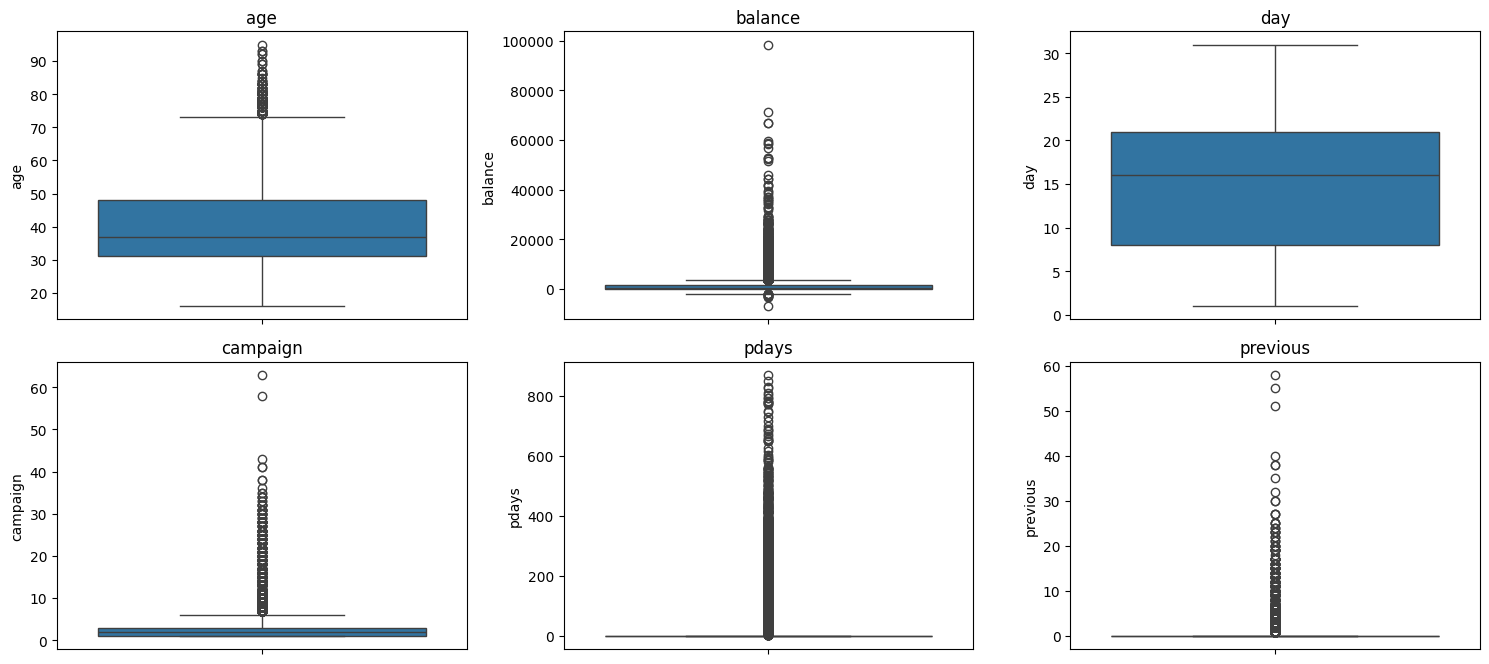


Outliers in age (z-score > 3):
       age
17617   75
17654   83
17982   75
18701   90
18711   82
...    ...
27189   77
27201   77
27210   78
27231   77
27258   75

[184 rows x 1 columns]

Outliers in balance (z-score > 3):
       balance
44       12223
546      58544
1407     24299
1500     13308
1548     26765
...        ...
27004    13774
27151    16873
27203    10861
27204    11115
27223    16353

[447 rows x 1 columns]

Outliers in age (IQR method):
age
77     29
75     28
80     25
76     20
74     20
78     20
79     14
83     11
81      8
82      7
Name: count, dtype: int64

Outliers in balance (IQR method):
balance
6138       7
8304       7
5310       6
5057       5
3570       5
4401       5
9367       5
4389       4
3913       4
4436       4
Name: count, dtype: int64

Outliers in day (IQR method):
Series([], Name: count, dtype: int64)

Outliers in campaign (IQR method):
campaign
7           422
8           311
9           201
10          166
11          122
12           92
13

In [12]:
# 1. Basic statistics
print(data[numerical_features].describe())

# 2. Boxplots for visual inspection
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# 3. Z-score method for continuous variables
continuous_cols = ['age', 'balance']
for col in continuous_cols:
    z_scores = (data[col] - data[col].mean()) / data[col].std()
    outliers = data[abs(z_scores) > 3]
    print(f"\nOutliers in {col} (z-score > 3):")
    print(outliers[[col]])

# 4. IQR method for all numerical variables
for col in numerical_features:
    if col == 'pdays':  # Skip pdays as -1 is a special value
        continue
        
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"\nOutliers in {col} (IQR method):")
    print(outliers[[col]].value_counts().head(10))  # Show top 10 outlier values

As we have some outliers present, and we do not want to remove them as they could likely represent realistic large/small balances, we will cap any outliers to reduce their impact on the data.

In [13]:
#Transformer to Cap Outliers
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.lower_bounds_ = X.quantile(self.lower)
        self.upper_bounds_ = X.quantile(self.upper)
        return self

    def transform(self, X):
        return X.clip(self.lower_bounds_, self.upper_bounds_, axis=1)

We will finally combine our steps to create a preprocessing pipeline, combining our outlier handling with imputation. We will also add a normalisation function to help with our training.

In [14]:
# 6. Build Preprocessing Pipelines

numerical_transformer = Pipeline(steps=[
    ('outlier_capping', OutlierCapper(lower=0.01, upper=0.99)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

### Step 3: Feature Selection

For feature selection, we will use an selectKBest to do an initial reduction of our feature space, followed by a Recursive Feature Elimination function to perform an selection of our initally selected features. Logistic regression is used as it is not too computationally intensive. I found this combination to provide the best results.

In [15]:
# Feature selection pipeline
select_k_best = SelectKBest(score_func=f_classif, k=20)
rfe = RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=10)

### Step 4: Hyperperameter Testing

For hyperperameter testing, we will be using a grid search for each type of model we will be testing today (KNN, Random Forest, Naive Bayes and Logistic Regression) to find the best hyperparameters to use.

In [16]:
#Model Configurations for Grid Search
model_configs = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__criterion':['gini','entropy','log_loss'],
            'classifier__max_depth': [None, 10, 20],
            'classifier__max_leaf_nodes':[3,5,10,20,50],
            'classifier__class_weight': [None, 'balanced']
        }
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {}
    },
    'Logistic Regression': {
    'model': LogisticRegression(max_iter=1000),
    'params': [
        {   # l2 penalty: supports lbfgs, saga, liblinear
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs', 'saga', 'liblinear'],
            'classifier__class_weight': [None, 'balanced']
        },
        {   # l1 penalty: only saga and liblinear
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l1'],
            'classifier__solver': ['saga', 'liblinear'],  # lbfgs removed
            'classifier__class_weight': [None, 'balanced']
        }
    ]
},
    'Gradient Boosting': {
        'model': HistGradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_iter': [100, 200],
            'classifier__max_depth': [3, 5, None],
            'classifier__l2_regularization': [0.0, 0.1, 1.0]
        }
    }

}

### Step 5: Final Pipeline

The final pipeline can now be constructed, using our preprossing pipline and feature selection. We will also be oversampling on our 'TypeB' target value using SMOTE as there is a class imbalance in our target variable within the data as TypeA has far more records than TypeB

In [17]:
# Train and Evaluate Each Model
results = {}

for name, config in model_configs.items():
    print(f"\nTuning {name}...")

    steps = [
        ('preprocessor', preprocessor),    # Preprocessing step
        ('smote', SMOTE()),                # SMOTE step
        ('select_k_best', select_k_best),  # Feature selection step 1: SelectKBest
        ('rfe', rfe)                       # Feature selection step 2: RFE
    ]

    # Only add the 'to_dense' step for Naive Bayes if the data is sparse
    if name == 'Naive Bayes':
        steps.append(('to_dense', FunctionTransformer(lambda x: x.toarray() if issparse(x) else x, accept_sparse=True)))

    steps.append(('classifier', config['model']))
    pipeline = Pipeline(steps=steps)

    # GridSearchCV with the training data (we are choosing our parameters based on 'accuracy' as this was the goal of the assignment.
    grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)

    """
    #view selected features
    if hasattr(grid.best_estimator_.named_steps['feature_selection'], 'get_support'):
        preprocessor = grid.best_estimator_.named_steps['preprocessor']
        selector = grid.best_estimator_.named_steps['feature_selection']
        
        num_feats = preprocessor.named_transformers_['num'].named_steps['scaler'].get_feature_names_out(numerical_features)
        cat_feats = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
        all_features = np.concatenate([num_feats, cat_feats])
        
        selected_features = all_features[selector.get_support()]
        
        print(f"Top {len(selected_features)} selected features for {name}:")
        for feat in selected_features:
            print(f" - {feat}")
    """
    #predict on test data
    y_test_pred = grid.predict(X_test)

    # Calculate additional metrics
    test_precision = precision_score(y_test, y_test_pred, average='binary')
    test_recall = recall_score(y_test, y_test_pred, average='binary')
    test_f1 = f1_score(y_test, y_test_pred, average='binary')

    results[name] = {
        'Best Accuracy (Train)': grid.best_score_,
        'Test Accuracy': grid.score(X_test, y_test),
        'Best Params': grid.best_params_,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1 Score': test_f1,
        'model': grid
    }

    y_test_proba = grid.predict_proba(X_test)[:, 1]  # Probabilities for positive class (TypeB)
    fpr, tpr, _ = roc_curve(y_test, y_test_proba, pos_label= 1)
    auc_score = roc_auc_score(y_test, y_test_proba)

    results[name]['FPR'] = fpr
    results[name]['TPR'] = tpr
    results[name]['AUC'] = auc_score

    # Display the results
    print(f"{name} Test Accuracy: {grid.score(X_test, y_test):.4f}")
    print(f"Best Params: {grid.best_params_}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1 Score: {test_f1:.4f}")
    


Tuning KNN...


c:\Users\colin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\colin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\colin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\colin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

KNN Test Accuracy: 0.8841
Best Params: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
Test Precision: 0.5278
Test Recall: 0.2346
Test F1 Score: 0.3248

Tuning Random Forest...
Random Forest Test Accuracy: 0.8594
Best Params: {'classifier__class_weight': None, 'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__max_leaf_nodes': 50}
Test Precision: 0.4134
Test Recall: 0.4383
Test F1 Score: 0.4255

Tuning Naive Bayes...
Naive Bayes Test Accuracy: 0.8482
Best Params: {}
Test Precision: 0.3707
Test Recall: 0.3981
Test F1 Score: 0.3839

Tuning Logistic Regression...
Logistic Regression Test Accuracy: 0.7687
Best Params: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Test Precision: 0.2719
Test Recall: 0.5648
Test F1 Score: 0.3671

Tuning Gradient Boosting...
Gradient Boosting Test Accuracy: 0.8803
Best Params: {'classifier__l2_regularization': 0.0, 'classifier__learning_r

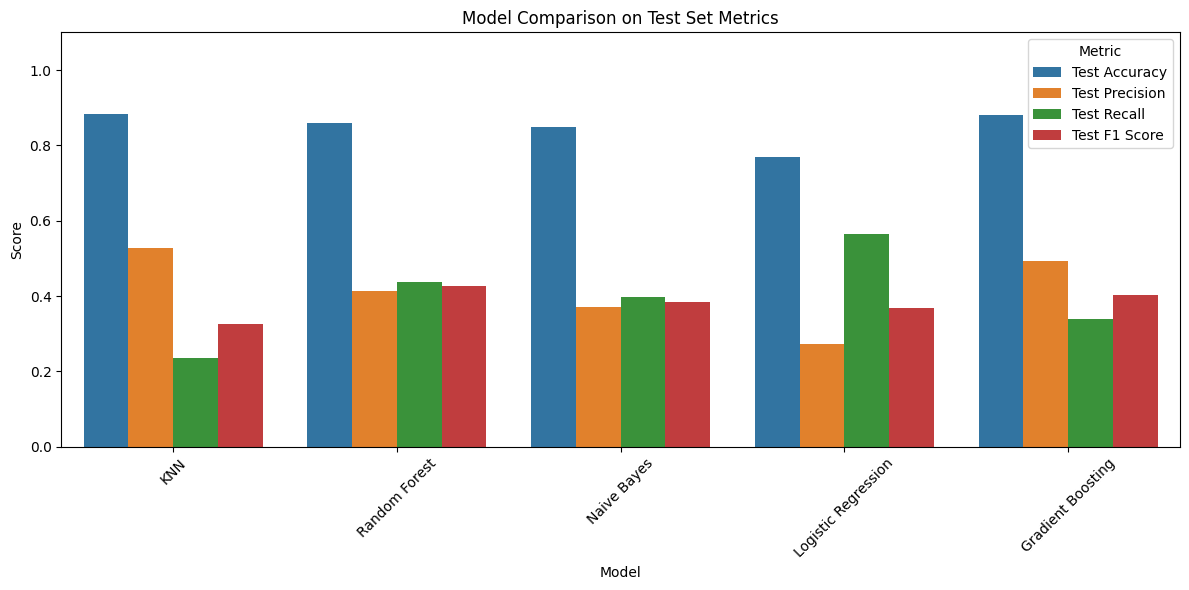

In [18]:
#plot testing results

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

# Melt the DataFrame for seaborn plotting (for Test metrics only)
melted = results_df.melt(id_vars='Model', 
                         value_vars=['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1 Score'],
                         var_name='Metric', 
                         value_name='Score')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison on Test Set Metrics')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

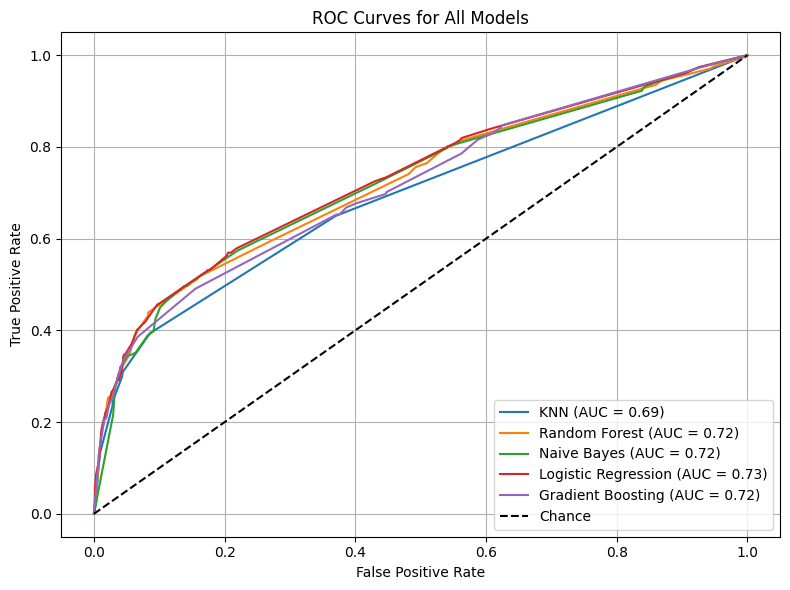

In [19]:
#Plot ROC curves
plt.figure(figsize=(8, 6))

for model_name, res in results.items():
    if 'FPR' in res and 'TPR' in res:
        plt.plot(res['FPR'], res['TPR'], label=f"{model_name} (AUC = {res['AUC']:.2f})")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 6: Model Results Analysis/Selection

Looking at the overall model performance, we can see that class imbalance is likely still present in the data (or something that I am missing) which is leading ot low recall/precision/F1 scores across most models.

High accuracy (e.g. Knn; 88.4%) seems to be missleading in this case as the high accuracy also comes with poor recall/F1 indicates modesl are biased towards the majority class.

In terms of model specific analysis:

K-Nearest Neighbors (KNN)

    Strengths: Highest accuracy (88.4%) and precision (52.8%).

    Weaknesses: Very low recall (23.5%), failing to capture the minority class.

    Use Case: Only if false positives are costly (e.g., spam filtering).

Random Forest

    Strengths: Best F1 (0.4255), balanced precision (41.3%)/recall (43.8%).

    Weaknesses: Moderate precision.

    Key Insight: Handles imbalance better than KNN; good default choice.

Naive Bayes

    Strengths: Decent recall (39.8%) for a simple model.

    Weaknesses: Low precision (37.1%), prone to false positives.

    Use Case: Quick baseline but outperformed by ensemble methods.

Logistic Regression

    Strengths: Highest recall (56.5%), best for minimizing false negatives.

    Weaknesses: Low precision (27.2%)—many false positives.

    Use Case: If missing minority cases is unacceptable (e.g., disease diagnosis).

Gradient Boosting

    Strengths: High accuracy (88.0%) and strong precision (49.4%) among top models.

    Weaknesses: Recall (34.0%) lags behind Random Forest.


In terms of model selection, as we are unfamiliar with this particular use case in terms of the importance of accuracy vs. precision vs. recall, we will select the model that provides the best balance of precision and recall while maintaining a high accuracy, which in this case is Random Forrest


In [20]:
#Load query data
queries = pd.read_csv("queries.txt")

print(queries.head())

#Get the Random Forest Pipeline
best_model_pipeline = results['Random Forest']['model']

#Save original index for final output
new_data_index = queries.index

#Make predictions
predictions = best_model_pipeline.predict(queries)

# Map numeric predictions to label strings
label_map = {0: 'Type A', 1: 'Type B'}
formatted_predictions = [f"{i+1},{label_map[pred]}" for i, pred in enumerate(predictions)]

#Write predictions to a new CSV
output_df = pd.DataFrame({'Prediction': formatted_predictions})

with open('D24126843.txt', 'w') as f:
    for line in formatted_predictions:
        f.write(f"{line}\n")


print("\nPredictions saved to D24126843.txt")


   age       job  marital  education default  balance housing loan  contact  \
0   58   JobCat6  married   tertiary      no     2143     yes   no  unknown   
1   31   JobCat4  married  secondary      no        2     yes  yes  unknown   
2   33   JobCat6  married   tertiary      no      231     yes   no  unknown   
3   43   JobCat9   single  secondary      no      593     yes   no  unknown   
4   27  JobCat11   single  secondary      no      390     yes   no  unknown   

   day month  duration  campaign  pdays  previous poutcome  y  
0    5   may         0         1     -1         0  unknown  ?  
1    5   may         0         1     -1         0  unknown  ?  
2    5   may         0         1     -1         0  unknown  ?  
3    5   may         0         1     -1         0  unknown  ?  
4    5   may         0         1     -1         0  unknown  ?  

Predictions saved to D24126843.txt
